In [ ]:
import torch
import torch.nn as nn
from torchvision.datasets import MNIST
from torchvision.transforms import Compose, ToTensor, Normalize
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.nn import functional as F
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
train_set = MNIST("./MNIST_dataset", train=True, download=True, transform=Compose([ToTensor(), Normalize((0.1307,), (0.3081,))]))
test_set = MNIST("./MNIST_dataset", train=False, download=True, transform=Compose([ToTensor(), Normalize((0.1307, ),(0.3081, ))]))

In [ ]:
train_loader = DataLoader(dataset=train_set, batch_size=16, shuffle=True) 
test_loader = DataLoader(dataset=test_set, batch_size=16, shuffle=False)

In [ ]:
data_visual, target_visual = next(iter(train_loader))
print(f"The values of data visualized: {data_visual}, and \n the values of target visualized: {target_visual}")
print(f"The shape of data: {data_visual.shape} and the shape of target: {target_visual.shape}")

The values of data visualized: tensor([[[[-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          ...,
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242]]],


        [[[-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          ...,
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
          [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242]]],


        [[[-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.42

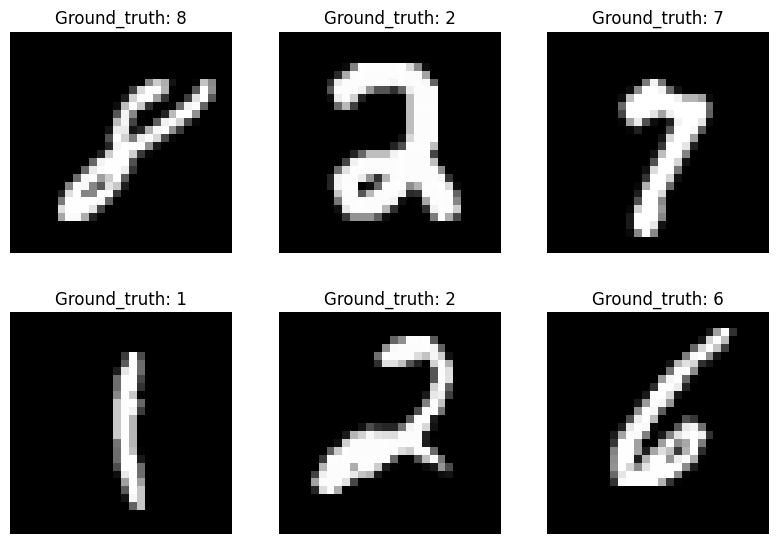

In [ ]:
fig = plt.figure(figsize=(8, 6))

for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.title("Ground_truth: {}".format(target_visual[i]))
    plt.tight_layout()
    plt.imshow(data_visual[i][0], cmap='gray')
    plt.axis("off")
    
plt.show(fig)


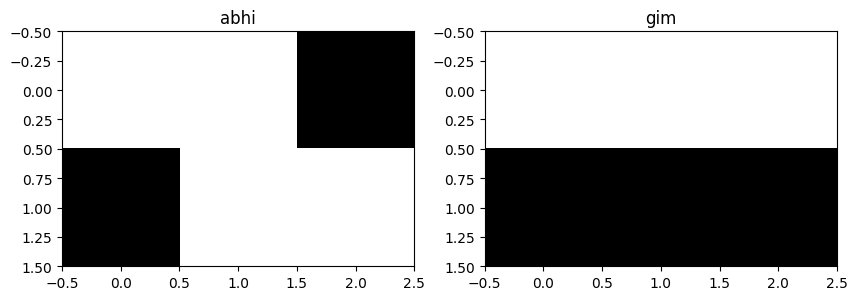

In [ ]:
name = ["abhi", "gim", "gemma"]

fig = plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
plt.title("{0}".format(name[0]))
plt.imshow(np.array([[0, 0, 1],
                     [1, 0, 0]]), cmap="binary")
plt.subplot(1, 2, 2)
plt.title("{0}".format(name[1]))
plt.imshow(np.array([[0, 0, 0],
                     [1, 1, 1]]), cmap="binary")

In [ ]:
class Classifer(nn.Module):
    def __init__(self, in_channel, out_channel):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels=in_channel, out_channels=8, kernel_size=5),
            nn.Tanh(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(in_channels=8, out_channels=32, kernel_size=5),
            nn.Tanh(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(in_features=32*4*4, out_features=64),
            nn.Tanh(),
            nn.Dropout(),
            
            nn.Linear(64, 32),
            nn.Tanh(),
            nn.Dropout(),
            
            nn.Linear(32, out_channel)
        )
        
    def forward(self, x):
        x = self.conv_block(x)
        x = x.view(x.shape[0], -1) # similar to x.view(x.size(0), -1) or nn.Flatten() basically used for keeping B from B, C, H, W
        x = self.classifier(x)
        return nn.Softmax(x)

In [ ]:
model = Classifer(in_channel=1, out_channel=10)

In [ ]:
data_visual.view(-1, 28).shape

torch.Size([448, 28])

In [ ]:
x = torch.randn(16, 32, 4, 4)
x.shape

torch.Size([16, 32, 4, 4])

In [ ]:
x.view(x.shape[0], -1).shape

torch.Size([16, 512])

In [ ]:
epochs = 50
criterion = nn.CrossEntropyLoss()
alpha = 1e-4

In [ ]:
optimizer = optim.Adam(params=model.parameters(), lr=alpha)